# Imports and Global Variables

In [1]:
import numpy as np
import pandas as pd 
import fastf1 as f
import fastf1.plotting as p
from matplotlib import rcParams, pyplot as plt
import seaborn as sns 
import import_ipynb
from math import ceil

In [2]:
from data_transformation import compound_selection_2021, compound_selection_2022, num_rounds_2021, num_rounds_2022

importing Jupyter notebook from data_transformation.ipynb


utils          INFO 	Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
utils          INFO 	NumExpr defaulting to 8 threads.


In [3]:
f.Cache.enable_cache("D:\Projects\F1 Tyre Deep Dive\Cache")

In [4]:
slick_tyre_names = ["SOFT", "MEDIUM", "HARD"]

relative_compound_palette = {"SOFT":"#da291c", "MEDIUM":"#fed12e", "HARD":"#eeeeea", "INTERMEDIATE":"#43b02a", "WET":"#0166ac", "UNKNOWN":"#40e040"}
relative_compound_markers = {"SOFT":'o', "MEDIUM":'^', "HARD":'s', "INTERMEDIATE":'P', "WET":'X', "UNKNOWN":'.'}
relative_compound_labels = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]

# The absolute_compound_palette uses the 2018 colors in order of ultrasoft to hard
absolute_compound_palette = {'C1':"#00a2f3", 'C2': "#eeeeea", 'C3': "#fed12e", 'C4':"#da291c", 'C5':"#b24ba7", "INTERMEDIATE":"#43b02a", "WET":"#0166ac"}
absolute_compound_markers = {'C1':"P", "C2":'s', "C3":'^', "C4":'o', "C5":'D', "INTERMEDIATE":'P', "WET":'X', "UNKNOWN":'.'}
absolute_compound_labels = ["C1", "C2", "C3", "C4", "C5", "INTERMEDIATE", "WET"]

FreshTyre_markers = {True:'o', False:'X'}

In [5]:
sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})

# Load Dataframes 

In [6]:
df_laps_2021 = pd.read_csv("transformed_laps_2021.csv", header=0, index_col=0, parse_dates=["LapStartDate"], infer_datetime_format=True, true_values=["True"], false_values=["False"])
df_laps_2022 = pd.read_csv("transformed_laps_2022.csv", header=0, index_col=0, parse_dates=["LapStartDate"], infer_datetime_format=True, true_values=["True"], false_values=["False"])

In [7]:
df_laps_2021[["Time", "LapTime", "PitInTime", "PitOutTime", "Sector1Time", "Sector2Time", "Sector3Time", "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", "LapStartTime", "DeltaToRep", "DeltaToFastest", "DeltaToLapRep"]] = df_laps_2021[["Time", "LapTime", "PitInTime", "PitOutTime", "Sector1Time", "Sector2Time", "Sector3Time", "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", "LapStartTime", "DeltaToRep", "DeltaToFastest", "DeltaToLapRep"]].apply(pd.to_timedelta)
df_laps_2022[["Time", "LapTime", "PitInTime", "PitOutTime", "Sector1Time", "Sector2Time", "Sector3Time", "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", "LapStartTime", "DeltaToRep", "DeltaToFastest", "DeltaToLapRep"]] = df_laps_2022[["Time", "LapTime", "PitInTime", "PitOutTime", "Sector1Time", "Sector2Time", "Sector3Time", "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", "LapStartTime", "DeltaToRep", "DeltaToFastest", "DeltaToLapRep"]].apply(pd.to_timedelta)


# Visualization Functions

## Tyre Usage

In [8]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%  ({v:d})'.format(p=pct,v=val)
    return my_autopct

In [9]:
def tyre_usage_pie(year, title=None, events=None, drivers=None, slick_only=True, absolute_compound=False):
    
    """
    Make tyre usage pie chart that allows filtering by events, drivers, and slick vs wet tyres
    
    Args:
        year: int {2021, 2022}
            Championship year
        
        title: str, default:None
            
        events: list, default: None
            A list containing the round number (as int) or the names of events
            e.g. [1, "Hungary", "British Grand Prix", "Monza"]
            Name fuzzy matching provided by fastf1.get_event()
            Using the default value will select all events
            
        drivers: list, default:None
            A list containing three-letter driver abbreviations 
            e.g. ["VER", "HAM"]
            Using the default value will select all drivers
            
        slick_only: bool, default:True
            If true, only laps raced on slick tyres are counted
            If false, all laps (with known tyre compound) are counted
            
        absolute_compound: bool, default:False
            If true, group tyres by their absolute compound names (C1, C2 etc.)
            If false, group tyres by their names in the respective events (SOFT, MEDIUM, HARD)
          
    Returns: Figure object
    """    
    included_laps = pd.DataFrame()
    
    if year == 2021:
        included_laps = df_laps_2021
    elif year == 2022:
        included_laps = df_laps_2022
    else:
        raise ValueError("Year requested ({}) not available".format(year))
    
    if events is None:
        events = pd.unique(included_laps["RoundNumber"])
    else:
        events = [f.get_event(year, event)["RoundNumber"] if isinstance(event, str) else event for event in events]
        
    if drivers is None:
        drivers = pd.unique(included_laps["DriverNumber"])

    if slick_only:
        included_laps = included_laps[included_laps["IsSlick"] == True]  

    included_laps = included_laps[(included_laps["RoundNumber"].isin(events)) & (included_laps["DriverNumber"].isin(drivers))]
    
    
    fig, ax = plt.subplots(figsize=(10,6))
    plt.style.use("default")
    
    if absolute_compound:
        lap_counts = included_laps.groupby("CompoundName").count()
        labels = lap_counts.index
        palette = [absolute_compound_palette[label] for label in labels]

        # Driver column is used because it is not nullable and therefore holds the correct count
        counts = [lap_counts.loc[i]["Driver"] for i in labels]
        
        wedges, texts, autotexts = ax.pie(x=counts, 
                                          labels=lap_counts.index, 
                                          colors=palette, 
                                          autopct=make_autopct(counts), 
                                          counterclock=False, 
                                          startangle=90)
    else:
        lap_counts = included_laps.groupby("Compound").count()
        labels = lap_counts.index
        counts = [lap_counts.loc[i]["Driver"] for i in lap_counts.index]
        palette = [relative_compound_palette[label] for label in labels]

        wedges, texts, autotexts = ax.pie(x=counts, 
                                          labels=labels, 
                                          colors=palette, 
                                          autopct=make_autopct(counts), 
                                          counterclock=False, 
                                          startangle=90)

    ax.legend(labels=labels, title="Compound Names", loc="best")
    ax.axis("equal")
    ax.set_title(title)
    plt.setp(autotexts, size=12)
    plt.show()
    
    return fig

## Lap Time Scatterplot

### Lap Times by Event and Drivers

In [10]:
def lap_filter_round_driver(row, round_number, drivers):
    """
    Filter by round number and drivers    
    """
    
    return row.loc["RoundNumber"] == round_number and row.loc["Driver"] in drivers 

In [11]:
def lap_filter_upper_accurate(row, upper_bound):
    """
    Filter by IsAccurate and upper bound
    """
    
    if upper_bound is None:
        upper_bound = 50
    
    return row.loc["PctFromFastest"] < upper_bound and row.loc["IsAccurate"]

In [12]:
def plot_args(absolute_compound):
    """
    Given the input argument, return a list of the corresponding arguments to be supplied to the plotting function
    
    Args:
        absolute_compound: bool
            If true, use absolute compound names (C1, C2 ...) in legend
            Else, use relative compound names (SOFT, MEDIUM, HARD) in legend
    
    Returns: tuple
        (hue, palette, marker, labels)
    """    
    if absolute_compound:
        return ("CompoundName", absolute_compound_palette, absolute_compound_markers, absolute_compound_labels)
    else:
        return ("Compound", relative_compound_palette, relative_compound_markers, relative_compound_labels)

In [13]:
def reorder_legend(labels):
    """
    Given the list of labels, return a list of int that specifies their appropriate order in the legend
    
    e.g. labels = ["MEDIUM", "HARD", "SOFT"]
         desired = ["SOFT", "MEDIUM", "HARD"]
         return [2, 0, 1]
         
         labels = ["C3", "C1", "WET"]
         desired = ["C1", "C3", "WET"],
         return [1, 0, 2]
    """
    
    order = []
    old_indices = list(range(len(labels)))
    
    if "SOFT" in labels or "MEDIUM" in labels or "HARD" in labels:
        pos = [relative_compound_labels.index(label) if label in relative_compound_labels else -1 for label in labels]
        order = [old_index for sorted_index, old_index in sorted(zip(pos, old_indices))]
    else:
        pos = [absolute_compound_labels.index(label) if label in absolute_compound_labels else -1 for label in labels]
        order = [old_index for sorted_index, old_index in sorted(zip(pos, old_indices))]
    
    return order


In [14]:
def plot_driver_lap_times(year, event, drivers, y, upper_bound=10, absolute_compound=False):
    """
    Plot lap times for selected year, event, and drivers
    
    Only laps with IsAccurate=True will be plotted.
        
    Args:
        year: int {2021, 2022}
            Championship year
            
        event: int or str
            Round number or name of the event
            Name is fuzzy matched by fastf1.get_event()
        
        drivers: list
            List of the three-letter abbreviations of the drivers to be included 
            
        y: str, default
            Name of the column to be used as the y-axis.
            
        upper_bound: float, default: 10
            The upper bound of PctFromFastest for the laps to include
            
            If None, upper bound is set to 30. Use this setting for wet races!
            
            e.g. By default, only laps that are no more than 10% slower than the fastest lap are plotted 
        
        absolute_compound: bool, default: False
            If True, use absolute compound palette (C1, C2 etc.)
            
            If False, use relative compound palette (SOFT, MEDIUM, HARD)
        
    Returns: Figure
    """    
    
    max_width = 4
    
    plt.style.use("dark_background")
    
    fontdict = {'fontsize': rcParams['axes.titlesize'],
                'fontweight': rcParams['axes.titleweight'],
                'color': rcParams['axes.titlecolor'],
                'verticalalignment': 'baseline',
                'horizontalalignment': "center"}
    
    num_row = ceil(len(drivers) / max_width)
    num_col = len(drivers) if len(drivers) < max_width else max_width
    fig, axes = plt.subplots(nrows=num_row, ncols=num_col, sharey=True, sharex=True, figsize=(5*num_col, 5*num_row))
    
    # Prevent TypeError when only one driver is plotted
    if len(drivers) == 1:
        axes = np.array([axes])

    event_info = f.get_event(year, event)
    round_number = event_info["RoundNumber"]
    event_name = event_info["EventName"]
    
    included_laps = pd.DataFrame()
    args = plot_args(absolute_compound)
    
    if year == 2021:
        included_laps = df_laps_2021[df_laps_2021.apply(lambda row: lap_filter_round_driver(row, round_number, drivers), axis=1)]
    elif year == 2022:
        included_laps = df_laps_2022[df_laps_2022.apply(lambda row: lap_filter_round_driver(row, round_number, drivers), axis=1)]
    else:
        raise ValueError("Year requested ({}) not available".format(year))
        
    for i in range(len(drivers)):
        row = i // max_width
        col = i % max_width
        
        ax = axes[row][col] if num_row > 1 else axes[col]
        
        driver_color = p.driver_color(drivers[i])
        driver_laps = included_laps[included_laps["Driver"]==drivers[i]]
        
        pit_in_laps = driver_laps[driver_laps["PitInTime"].notnull()]["LapNumber"].to_numpy()
        
        # After pitstops are identified, we can filter for IsAccurate=True and upper_bound
        driver_laps = driver_laps[driver_laps.apply(lambda row: lap_filter_upper_accurate(row, upper_bound), axis=1)]
            
        sns.scatterplot(data=driver_laps, 
                        x="LapNumber", 
                        y=y, 
                        ax=ax, 
                        hue=args[0], 
                        palette=args[1],
                        hue_order=args[3],
                        style="FreshTyre",
                        style_order = [True, False],
                        markers=FreshTyre_markers,
                        legend='auto' if i == num_col-1 else False)
        
        ax.vlines(ymin=plt.yticks()[0][1], ymax=plt.yticks()[0][-2], x=pit_in_laps, label="Pitstop", linestyle="dashed")

        fontdict["color"] = driver_color 
        ax.set_title(label=drivers[i], fontdict=fontdict, fontsize=12)
        
        ax.grid(color=driver_color, which='both', axis='both')
        sns.despine(left=True, bottom=True)
                
    fig.suptitle(t="{} {}".format(year, event_name), fontsize=20)
    axes.flatten()[num_col-1].legend(loc='best', fontsize=8, framealpha=0.5)
    plt.show()
    
    return fig

### Compound Head-to-Head Line Chart

In [15]:
def lap_filter_round_compound_valid_upper(row, round_number, compounds, upper_bound):
    '''
    Filter by round number, whether lap is valid, compound name, and upper bound
    '''
    return row.loc["RoundNumber"] == round_number and row.loc["IsValid"] and row.loc["Compound"] in compounds and row.loc["PctFromFastest"] < upper_bound

In [16]:
def convert_compound_names(year, round_number, compounds):
    """
    Convert relative compound names to absolute names 
    
    Args:
        compounds: list of str {"SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"}
    
    Returns:
        comp_names: tuple of str {"C1", "C2", "C3", "C4", "C5", "INTERMEDIATE", "WET"}
        
    """
    compound_to_index = {"SOFT":2, "MEDIUM":1, "HARD":0}
    
    return_value = []
    
    for compound in compounds:
        if compound not in slick_tyre_names:
            return_value.append(compound)
        else:
            if year == 2021:
                return_value.append('C' + str(compound_selection_2021[round_number][compound_to_index[compound]]))
            elif year == 2022:
                return_value.append('C' + str(compound_selection_2022[round_number][compound_to_index[compound]]))
    
    return tuple(return_value)


In [17]:
def plot_compounds_lineplot(years, events, y, compounds=["SOFT", "MEDIUM", "HARD"], x="TyreLife", upper_bound=10, absolute_compound=True):
    """
    Plot lineplot for selected y column by event
        
    Caveats:
        Only laps with IsValid=True are considered
    
    Args:
        years: list of int or str
            Championship years of the events
        
        events: list of int or str
            A mix of round numbers or names of the events
            Name is fuzzy matched by fastf1.get_event()
        
        Each (year, event) pair should uniquely identify an event
        
        y: str
            The column to use as the y-axis.
        
        compounds: list of str {"SOFT", "MEDIUM", "HARD"}, default: ["SOFT", "MEDIUM", "HARD"]
            The compounds in the head-to-head
            
        x: str {"TyreLife", "LapNumber"} recommended, default: "TyreLife"
            The column to use as the x-axis

        upper_bound: float, default: 10
            The upper bound of PctFromFastest for the laps to include
            
            If None, upper bound is set to 30. Use this setting for wet races!
            
            e.g. By default, only laps that are no more than 10% slower than the fastest lap are plotted 
        
        absolute_compound: bool, default: True
            If True, use absolute compound palette (C1, C2 etc.)
            
            If False, use relative compound palette (SOFT, MEDIUM, HARD)
        
    Returns: Figure
    """
    
    assert years and events and len(years) == len(events), "years arg size ({}) does not match events arg size ({})".format(len(years), len(events))
    
    # unpack
    compounds = [compound.upper() for compound in compounds]
    
    for index, compound in enumerate(compounds):
        assert compound in slick_tyre_names, "compound arg {} does not name a slick tyre type".format(compound)
            
    if not absolute_compound:
        print('''
              WARNING: Different events may use different compounds under the same name!
                       e.g. SOFT may be any of C3 to C5 dependinging on the event
              ''')
        
    if x != "LapNumber" and x != "TyreLife":
        print('Using {} as the x-axis is not recommended. The recommended arguments are LapNumber and TyreLife'.format(x))
    
    # Combine years and events and get FastF1 event objects
    event_objects = [f.get_event(years[i], events[i]) for i in range(len(years))]

    plt.style.use("dark_background")
    fig, axes = plt.subplots(nrows=len(event_objects), sharex=True, ncols=1, figsize=(5, 5*len(event_objects)))
    
    # Prevent TypeError when only one event is plotted
    if len(events) == 1:
        axes = [axes]
    
    included_laps_df_list = []
            
    for year, event in zip(years, event_objects):
        df_eligible_laps = pd.DataFrame()
        
        if year == 2021:
            df_eligible_laps = df_laps_2021[df_laps_2021.apply(lambda row: lap_filter_round_compound_valid_upper(row, event["RoundNumber"], compounds, upper_bound), axis=1)]
        elif year == 2022:
            df_eligible_laps = df_laps_2022[df_laps_2022.apply(lambda row: lap_filter_round_compound_valid_upper(row, event["RoundNumber"], compounds, upper_bound), axis=1)]
        else:
            raise ValueError("Year requested ({}) not available".format(year))

        included_laps_df_list.append(df_eligible_laps)
        
    args = plot_args(absolute_compound)
    
    # Copy compounds values
    # May need to convert from relative to absolute names when plotting
    compounds_copy = compounds
 
    for i in range(len(event_objects)):
        included_laps = included_laps_df_list[i]
        medians = included_laps.groupby([args[0], x])[y].median()
        
        if absolute_compound:
            compounds_copy = convert_compound_names(years[i], event_objects[i]["RoundNumber"], compounds)
                                        
        for compound in compounds_copy:
            ax = sns.lineplot(x=medians.loc[compound].index, 
                              y=medians.loc[compound].values, 
                              ax=axes[i], 
                              color=args[1][compound],
                              marker=args[2][compound],
                              ms=4,
                              label=compound)

        
        
        handles, labels = axes[i].get_legend_handles_labels()
        order = reorder_legend(labels)
        axes[i].legend(handles=[handles[idx] for idx in order], 
                       labels=[labels[idx] for idx in order], 
                       loc="best", 
                       title=args[0],
                       frameon=True,
                       fontsize=10,
                       framealpha=0.5)
        
        ax.set_title(label="{} {}".format(years[i], event_objects[i]["EventName"]), fontsize=12)
        ax.grid(which="both", axis='y')
        sns.despine(left=True, bottom=True)
                
    # reorder compound names for title
    compounds = [compounds[i] for i in reorder_legend(compounds)]
    
    fig.suptitle(t=" VS ".join(compounds), fontsize="16")
    plt.show()
    
    return fig

### Compound Head-to-Head Boxplot

In [18]:
def plot_compounds_boxplot(years, events, y, compounds=["SOFT", "MEDIUM", "HARD"], x="TyreLife", upper_bound=10, absolute_compound=True ):
    """
    Plot boxplot for selected y axis by event
        
    Caveats:
        Only laps with IsValid=True are considered
    
    Args:
        years: list of int or str
            Championship years of the events
        
        events: list of int or str
            A mix of round numbers or names of the events
            Name is fuzzy matched by fastf1.get_event()
        
        (each (year, event) pair should uniquely identify an event)
        
        y: str
            The column to use as the y-axis.
        
        compounds: list of str {"SOFT", "MEDIUM", "HARD"}, default: ["SOFT", "MEDIUM", "HARD"]
            The compounds in the head-to-head
            
        x: str {"TyreLife", "LapNumber"} recommended, default: "TyreLife"
            The column to use as the x-axis

        upper_bound: float, default: 10
            The upper bound of PctFromFastest for the laps to include
            
            If None, upper bound is set to 30. Use this setting for wet races!
            
            e.g. By default, only laps that are no more than 10% slower than the fastest lap are plotted 
        
        absolute_compound: bool, default: True
            If True, use absolute compound palette (C1, C2 etc.)
            
            If False, use relative compound palette (SOFT, MEDIUM, HARD)
        
    Returns: Figure
    """
    
    assert years and events and len(years) == len(events), "years arg size ({}) does not match events arg size ({})".format(len(years), len(events))
    
    # unpack
    compounds = [compound.upper() for compound in compounds]
    
    for index, compound in enumerate(compounds):
        assert compound in slick_tyre_names, "compound arg {} does not name a slick tyre type".format(compound)
            
    if not absolute_compound:
        print('''
              WARNING: Different events may use different compounds under the same name!
                       e.g. SOFT may be any of C3 to C5 dependinging on the event
              ''')
    
    if x != "LapNumber" and x != "TyreLife":
        print('Using {} as the x-axis is not recommended. The recommended arguments are LapNumber and TyreLife'.format(x))
    
    # Combine years and events and get FastF1 event objects
    event_objects = [f.get_event(years[i], events[i]) for i in range(len(years))]

    plt.style.use("dark_background")
    fig, axes = plt.subplots(nrows=len(event_objects), sharex=True, ncols=1, figsize=(10, 5*len(event_objects)))
    
    # Prevent TypeError when only one event is plotted
    if len(events) == 1:
        axes = [axes]
    
    included_laps_df_list = []
        
    for year, event in zip(years, event_objects):
        df_eligible_laps = pd.DataFrame()
        
        if year == 2021:
            df_eligible_laps = df_laps_2021[df_laps_2021.apply(lambda row: lap_filter_round_compound_valid_upper(row, event["RoundNumber"], compounds, upper_bound), axis=1)]
        elif year == 2022:
            df_eligible_laps = df_laps_2022[df_laps_2022.apply(lambda row: lap_filter_round_compound_valid_upper(row, event["RoundNumber"], compounds, upper_bound), axis=1)]
        else:
            raise ValueError("Year requested ({}) not available".format(year))

        included_laps_df_list.append(df_eligible_laps)
                
    args = plot_args(absolute_compound)
    
    # Copy compounds values
    # May need to convert from relative to absolute names when plotting
    compounds_copy = compounds
 
    for i in range(len(event_objects)):
        included_laps = included_laps_df_list[i]
        
        if absolute_compound:
            compounds_copy = convert_compound_names(years[i], event_objects[i]["RoundNumber"], compounds)

        ax = sns.boxplot(data=included_laps,
                             x=x,
                             y=y,
                             ax=axes[i],
                             hue=args[0],
                             palette=args[1])

        ax.set_ylabel(y, fontsize=12)
        xticks = ax.get_xticks()
        xticks = [tick+1 for tick in xticks if tick % 5 == 0]
        ax.set_xticks(xticks)
        ax.grid(which='both', axis='y')
                       
        handles, labels = axes[i].get_legend_handles_labels()
        order = reorder_legend(labels)
        axes[i].legend(handles=[handles[idx] for idx in order], 
                       labels=[labels[idx] for idx in order], 
                       loc="best", 
                       title=args[0],
                       frameon=True,
                       fontsize=10,
                       framealpha=0.5)
        
        ax.set_title(label="{} {}".format(years[i], event_objects[i]["EventName"]), fontsize=12)
        sns.despine(left=True, bottom=True)
    
    # reorder compound names for title
    compounds = [compounds[i] for i in reorder_legend(compounds)]
    
    fig.suptitle(t=" VS ".join(compounds), fontsize="16")
    plt.show()
    
    return fig

# 2021 VS 2022 Analysis

## Overall Trends

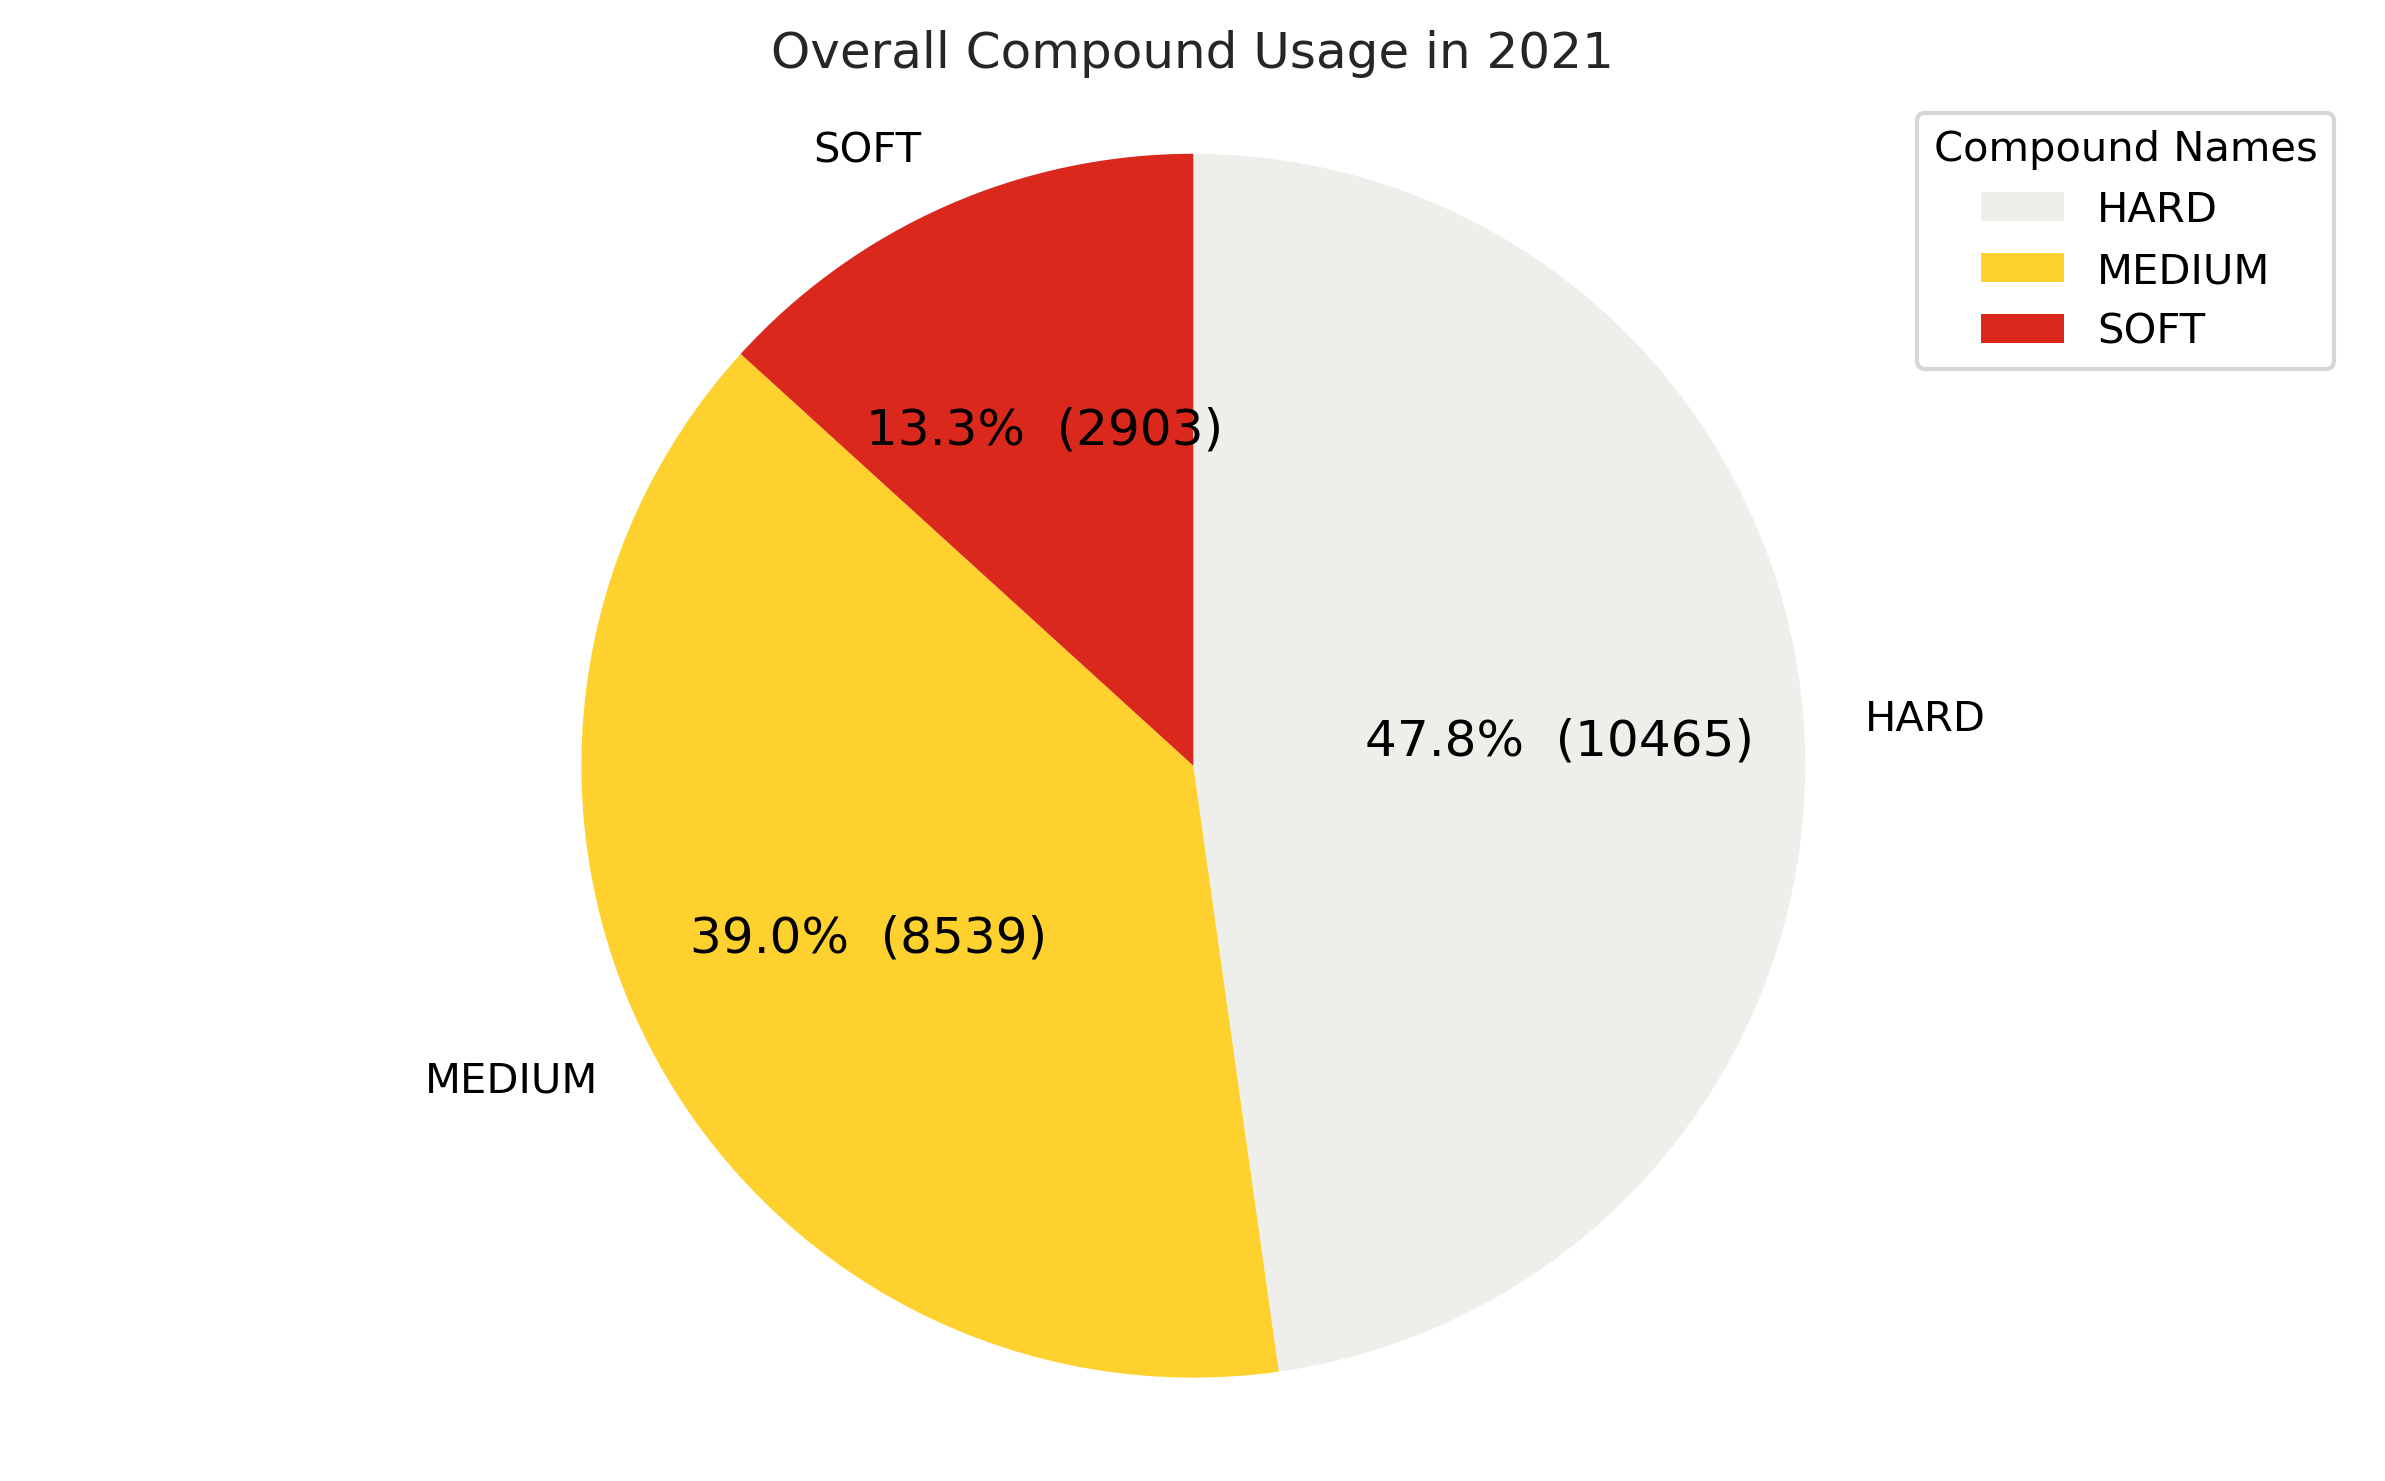

In [19]:
tyre_relative_use_2021 = tyre_usage_pie(2021, title="Overall Compound Usage in 2021")

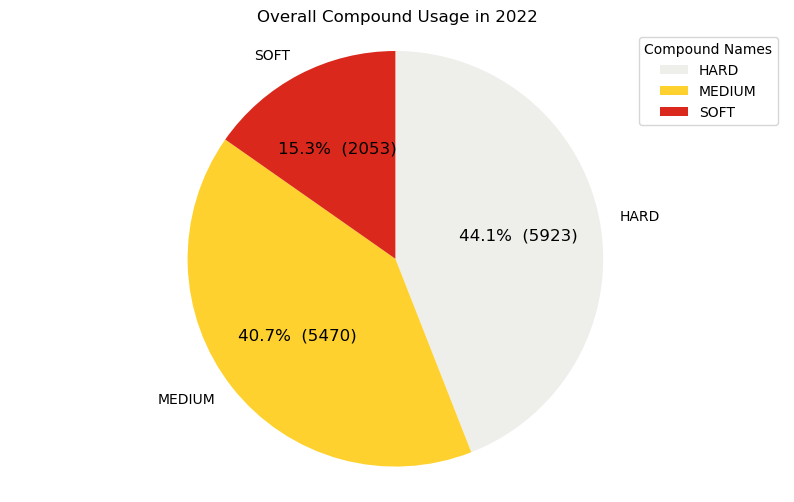

In [20]:
tyre_relative_use_2022 = tyre_usage_pie(2022, title="Overall Compound Usage in 2022")

In [21]:
compound_selection_freq_2021 = {i:0 for i in range(1,6)}
compound_selection_freq_2022 = {i:0 for i in range(1,6)}

In [22]:
for selections in compound_selection_2021.values():
    for selection in selections:
        compound_selection_freq_2021[selection] += 1
        
for selections in compound_selection_2022.values():
    for selection in selections:
        compound_selection_freq_2022[selection] += 1

In [23]:
compound_selection_freq_2021

{1: 5, 2: 17, 3: 23, 4: 18, 5: 6}

In [24]:
compound_selection_freq_2022

{1: 3, 2: 9, 3: 13, 4: 9, 5: 5}

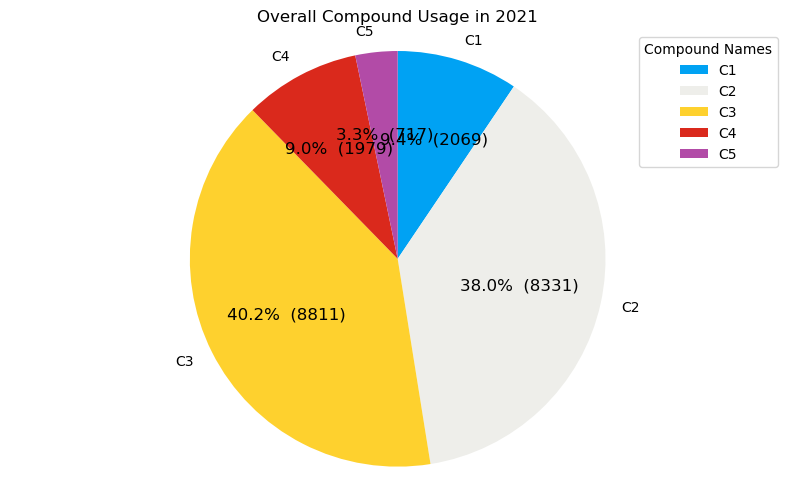

In [25]:
tyre_absolute_use_2021 = tyre_usage_pie(2021, title="Overall Compound Usage in 2021", absolute_compound=True)

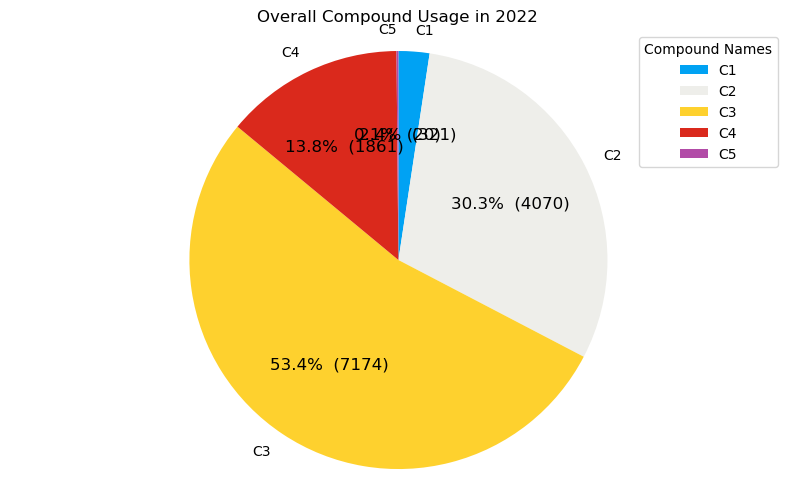

In [26]:
tyre_absolute_use_2022 = tyre_usage_pie(2022, title="Overall Compound Usage in 2022", absolute_compound=True)

At first glance, soft is used more frequently this season than last.

A further breakdown into the actual compound reveals that the softest compound (C5) is reserved for qualifying only. Only 20 laps has been completed on C5 compound this year compare to last year's 717. In both seasons, the C5 compound has been selected 6 times. 

C1 compound is also much less popular compared to last year. The "middle of the road" compounds seem to be the popular choice

## Circuit By Circuit Comparison

Among the races already completed in the 2022 season, the following ones were also present on the 2021 calendar:

- Bahrain
- Saudi Arabia
- Imola
- Monaco
- Spain
- Azerbaijan
- Great Britain
- Austria
- France 
- Hungary

Imola and Monaco will be dropped for this analysis due to rain at Imola in 2021 and at Monaco in 2022. The metrics I have designed do not handle wet races very well. 

Note that two races took place at Red Bull Ring in 2021 and they will both be studied. 

We will focus on average stint length and any crossover behavior between compounds.

### Sample Size Check
Certain compounds are underused at certain events and therefore we must proceed with caution when including them in the analysis. 

A good sample size is 200 laps and up. This signifies multiple stints by multiple drivers.

In [27]:
df_lap_count_2021 = df_laps_2021[['EventName', 'Compound', 'LapNumber']].groupby(['EventName', 'Compound']).count()

In [28]:
df_lap_count_2022 = df_laps_2022[['EventName', 'Compound', 'LapNumber']].groupby(['EventName', 'Compound']).count()

In [29]:
def avg_stint_length(year, event):
    '''
    Helper function to calculate average stint length of different compounds at the selected event
    '''
    
    df_included_laps = pd.DataFrame()
    
    # Unknown tyre compound mess up stint count. Laps with unknown compound will be ignored

    if year == 2021:
        round_number = f.get_event(year, event)["RoundNumber"]
        df_included_laps = df_laps_2021[(df_laps_2021["RoundNumber"] == round_number) & (df_laps_2021["Compound"] != "UNKNOWN")]
    elif year == 2022:
        round_number = f.get_event(year, event)["RoundNumber"]
        df_included_laps = df_laps_2022[(df_laps_2022["RoundNumber"] == round_number) & (df_laps_2022["Compound"] != "UNKNOWN")]
    else:
        raise ValueError("Year requested ({}) not available".format(year))
        
    stint_count = df_included_laps[["Stint", "Driver", "Compound"]].drop_duplicates().groupby("Compound").count()
    lap_count = df_included_laps[["Compound", "LapNumber"]].groupby("Compound").count()
                         
    avg_stint_length = {}
                         
    for compound in stint_count.index:
        avg_stint_length[compound] = round(lap_count.loc[compound, 'LapNumber'] / stint_count.loc[compound, 'Stint'], 1)
    
    return pd.DataFrame.from_dict(avg_stint_length, orient='index', columns=["Avg Stint Length"])

### Bahrain

In [30]:
print(df_lap_count_2021.loc["Bahrain Grand Prix"])
print(df_lap_count_2022.loc["Bahrain Grand Prix"])

          LapNumber
Compound           
HARD            417
MEDIUM          494
SOFT            115
UNKNOWN           1
          LapNumber
Compound           
HARD            103
MEDIUM          345
SOFT            674
UNKNOWN           1


In [31]:
print(avg_stint_length(2021, 'Bahrain'))
print(avg_stint_length(2022, 'Bahrain'))

        Avg Stint Length
HARD                19.9
MEDIUM              16.5
SOFT                12.8
        Avg Stint Length
HARD                14.7
MEDIUM              15.0
SOFT                13.8


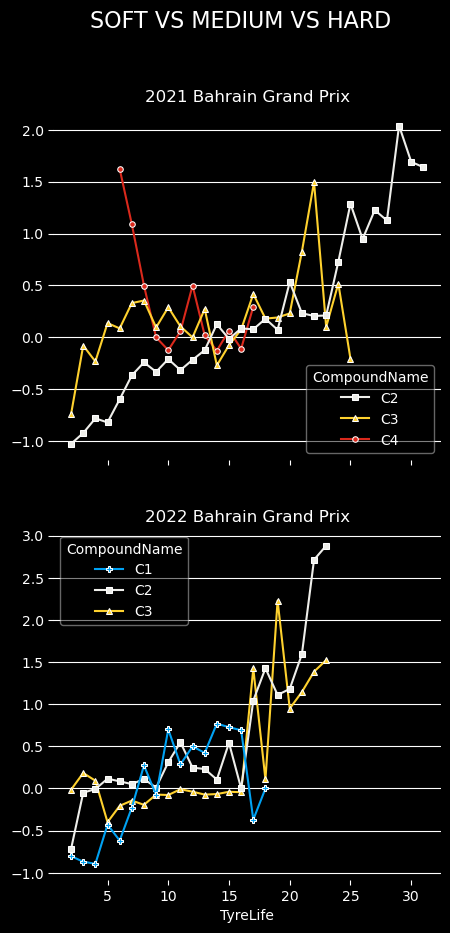

In [32]:
bahrain_line = plot_compounds_lineplot([2021, 2022], ['Bahrain', 'Bahrain'], 'PctFromLapRep', ['SOFT', 'MEDIUM', 'HARD'])

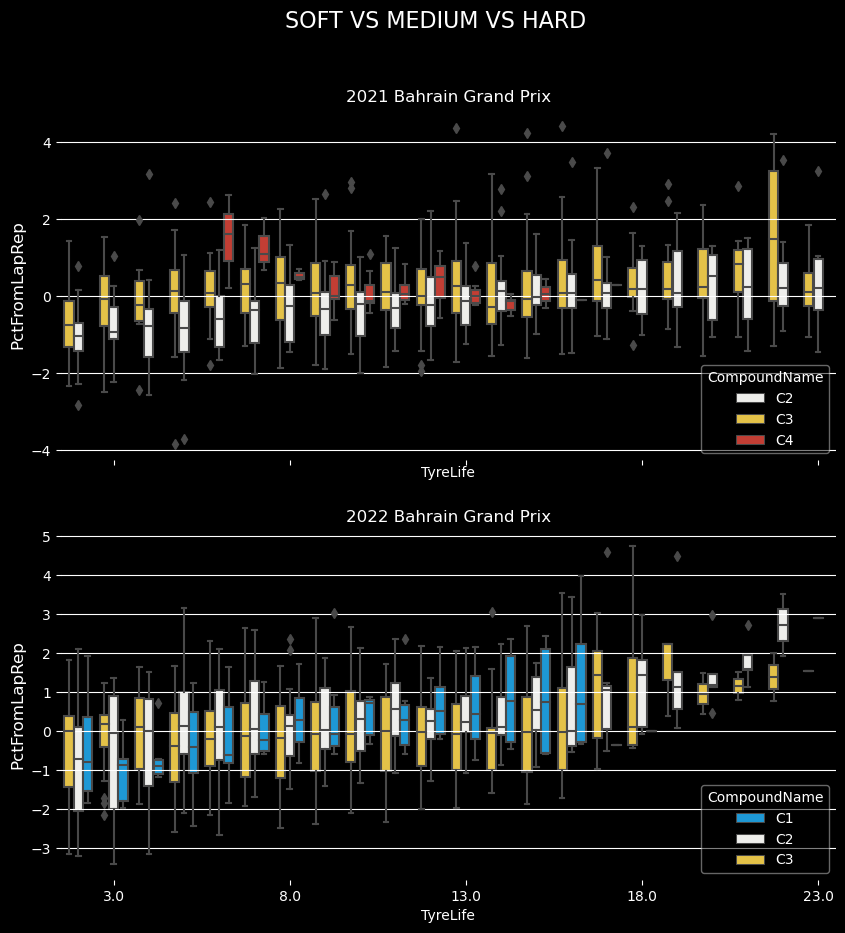

In [33]:
bahrain_box = plot_compounds_boxplot([2021, 2022], ['Bahrain', 'Bahrain'], 'PctFromLapRep', ['SOFT', 'MEDIUM', 'HARD'])

**Bahrain Analysis**

Soft compound (C4) under used in the 2021 race and hard compound (C1) under used in the 2022 race. C2 and C3 common race compounds in both season.

Average stint length is slightly longer in the 2021 season, especially on the hard compound. 

C2 consistently beats the other compounds regardless of tyre life in the 2021 season.

In the 2022 season, we see crossover trend between C2 and C3 around the 15 laps mark. Incidently, this corresponds with the average medium stint length of 15 laps.

In general, it seems C2 compound is not as competitive at Bahrain in 2022 vs 2021.



### Saudi Arabia

In [34]:
print(df_lap_count_2021.loc["Saudi Arabian Grand Prix"])
print(df_lap_count_2022.loc["Saudi Arabian Grand Prix"])

          LapNumber
Compound           
HARD            407
MEDIUM          423
SOFT             15
          LapNumber
Compound           
HARD            558
MEDIUM          259


In [35]:
print(avg_stint_length(2021, "Saudi Arabia"))
print(avg_stint_length(2022, "Saudi Arabia"))

        Avg Stint Length
HARD                11.3
MEDIUM              14.6
SOFT                 7.5
        Avg Stint Length
HARD                31.0
MEDIUM              13.6


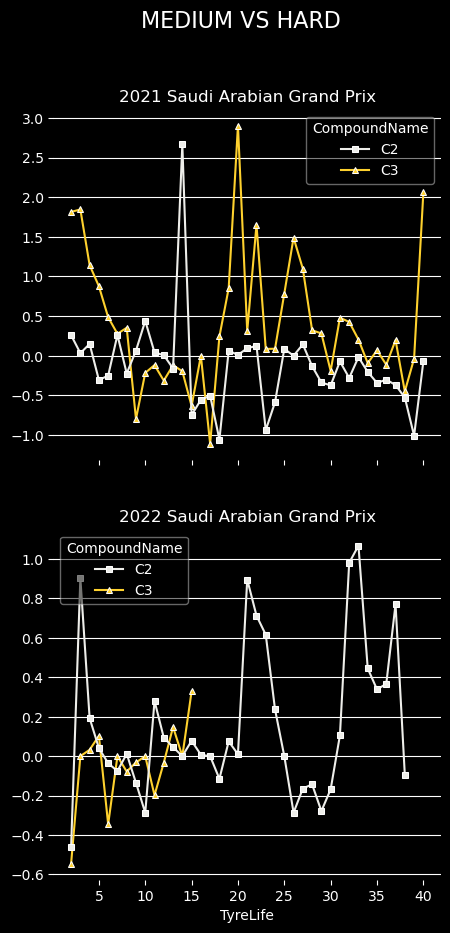

In [36]:
saudi_line = plot_compounds_lineplot([2021, 2022], ['Saudi Arabia', 'Saudi Arabia'], 'PctFromLapRep', ['MEDIUM', 'HARD'])

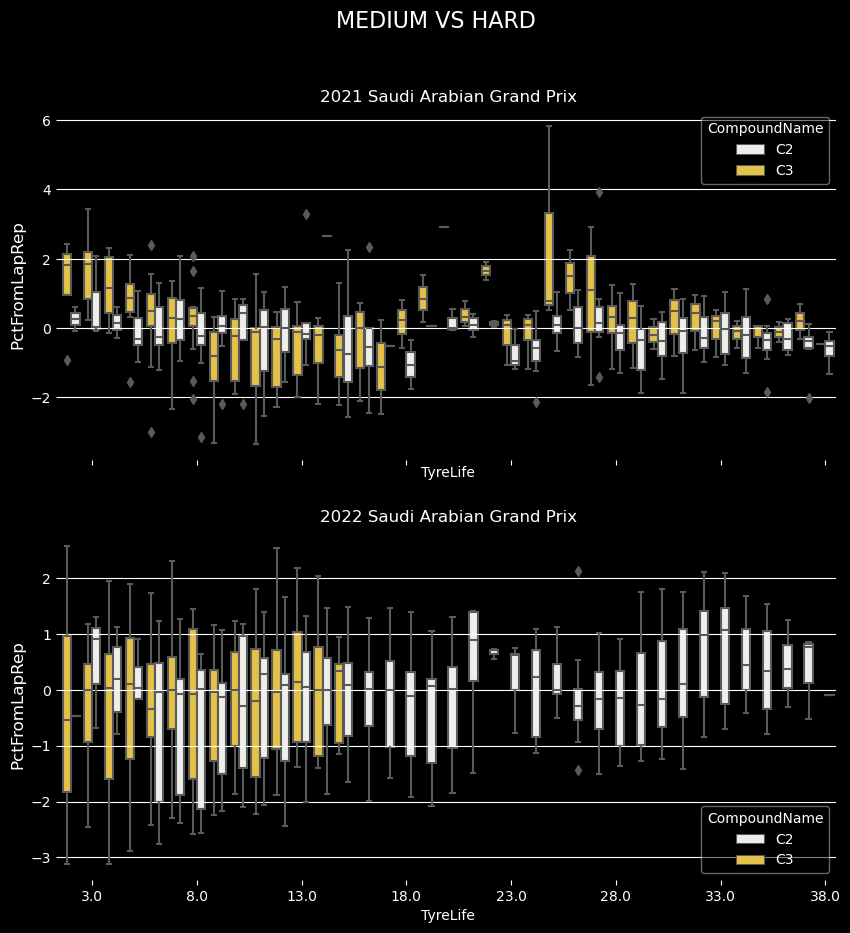

In [37]:
saudi_box = plot_compounds_boxplot([2021, 2022], ['Saudi Arabia', 'Saudi Arabia'], 'PctFromLapRep', ['MEDIUM', 'HARD'])

**Saudi Analysis**

Hard and medium compounds have good sample size for both year's races.

2021 average stint length output may not be accurate due to multiple red flags.

Zero long stints on C3 compound in the 2022 race, suggesting the compound is less durable vs 2021?

Seeing crossover trend at around 15 laps for 2022 and around 20 laps for 2021. 


### Imola

In [38]:
print(df_lap_count_2021.loc["Emilia Romagna Grand Prix"])
print(df_lap_count_2022.loc["Emilia Romagna Grand Prix"])

              LapNumber
Compound               
INTERMEDIATE        466
MEDIUM              448
SOFT                165
UNKNOWN              16
WET                  32
              LapNumber
Compound               
HARD                 32
INTERMEDIATE        329
MEDIUM              722
SOFT                 49


In [39]:
print(avg_stint_length(2021, "Emilia Romagna"))
print(avg_stint_length(2022, "Emilia Romagna"))

              Avg Stint Length
INTERMEDIATE              22.2
MEDIUM                    10.9
SOFT                      16.5
WET                        8.0
              Avg Stint Length
HARD                      32.0
INTERMEDIATE              15.7
MEDIUM                    40.1
SOFT                       9.8


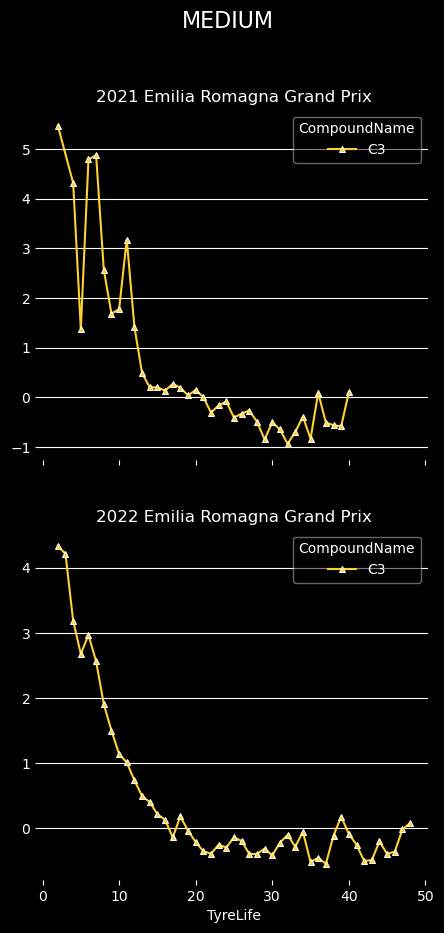

In [40]:
imola_line = plot_compounds_lineplot([2021, 2022], ["Emilia Romagna", "Emilia Romagna"], "PctFromRep", ["MEDIUM"])

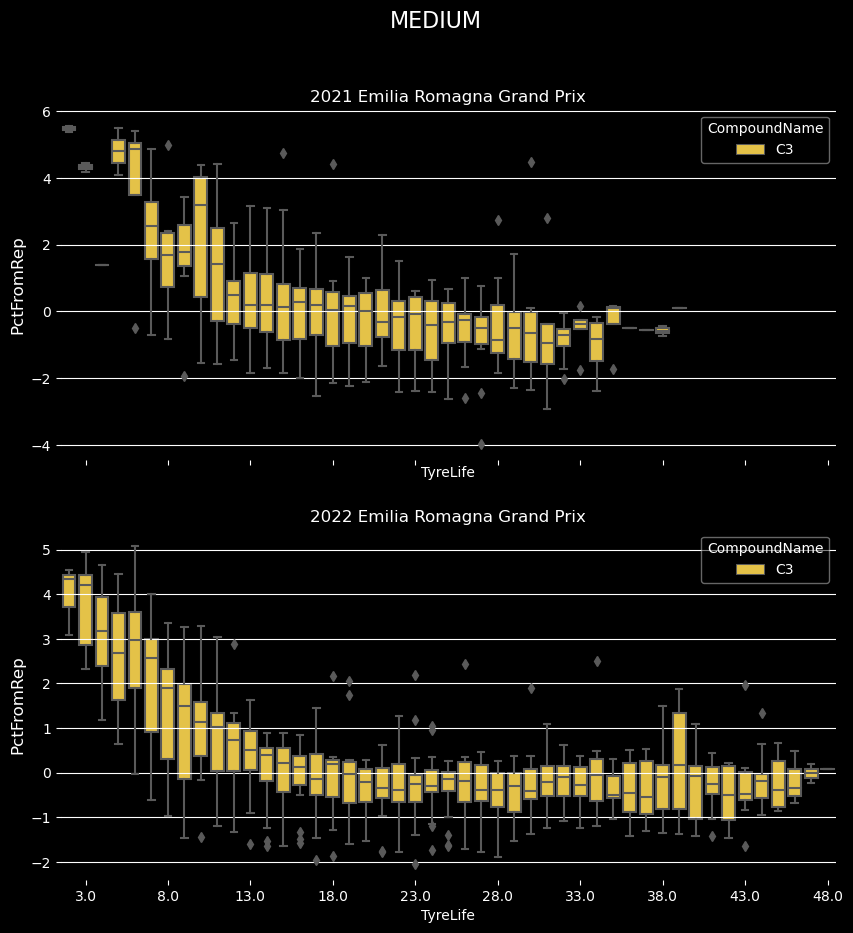

In [41]:
imola_box = plot_compounds_boxplot([2021, 2022], ["Emilia Romagna", "Emilia Romagna"], "PctFromRep", ["MEDIUM"])

**Imola Analysis**

Both races had some portion of wet running and only have good sample size on the medium (C3) compound.

Lap time improvement likely due to a combination of track evolution, lighter fuel load, and drying condition.

Similar deg curve.

### Monaco

In [42]:
print(df_lap_count_2021.loc["Monaco Grand Prix"])
print(df_lap_count_2022.loc["Monaco Grand Prix"])

          LapNumber
Compound           
HARD            714
MEDIUM          238
SOFT            468
              LapNumber
Compound               
HARD                416
INTERMEDIATE        141
MEDIUM              339
SOFT                  7
WET                 276


In [43]:
print(avg_stint_length(2021, "Monaco"))
print(avg_stint_length(2022, "Monaco"))

        Avg Stint Length
HARD                44.6
MEDIUM              39.7
SOFT                26.0
              Avg Stint Length
HARD                      15.4
INTERMEDIATE               8.8
MEDIUM                    28.2
SOFT                       7.0
WET                       11.0


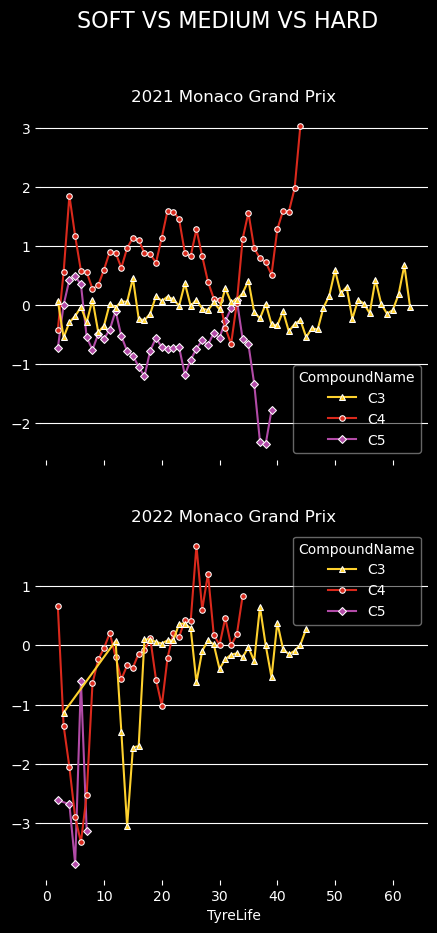

In [44]:
monaco_line = plot_compounds_lineplot([2021, 2022], ["Monaco", "Monaco"], "PctFromLapRep", x="TyreLife")

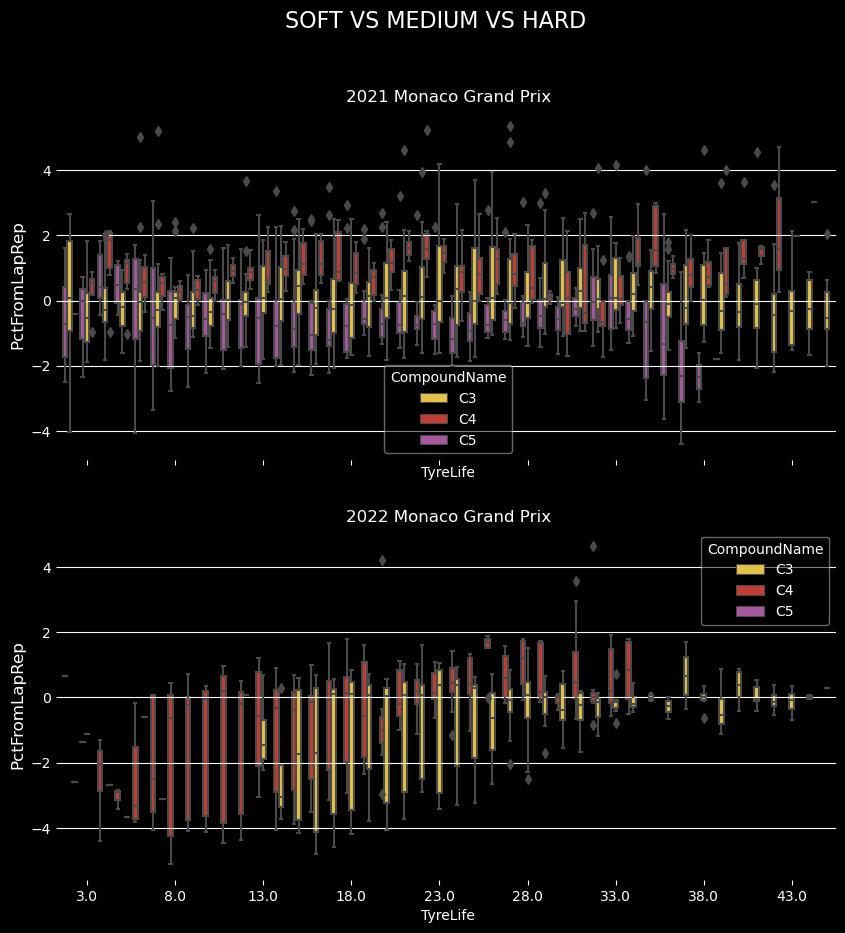

In [45]:
monaco_box = plot_compounds_boxplot([2021, 2022], ["Monaco", "Monaco"], "PctFromLapRep")

**Monaco Analysis**

Have good sample size for all three slick compounds in the 2021 race. Only have sufficient sample size for medium and hard in the 2022 race.

In the 2021 race, the ranking in race pace is consistently C5 > C3 > C4.This is reflected as the laps completed count is in the same order. No significant crossover trend.

In the 2022 race, suspected crossover trend between C3 and C4 around the 25 lap mark. 

### Spain

In [46]:
print(df_lap_count_2021.loc["Spanish Grand Prix"])
print(df_lap_count_2022.loc["Spanish Grand Prix"])

          LapNumber
Compound           
MEDIUM          630
SOFT            616
          LapNumber
Compound           
HARD             35
MEDIUM          513
SOFT            682


In [47]:
print(avg_stint_length(2021, "Spain"))
print(avg_stint_length(2022, "Spain"))

        Avg Stint Length
MEDIUM              26.2
SOFT                18.7
        Avg Stint Length
HARD                35.0
MEDIUM              18.3
SOFT                15.2


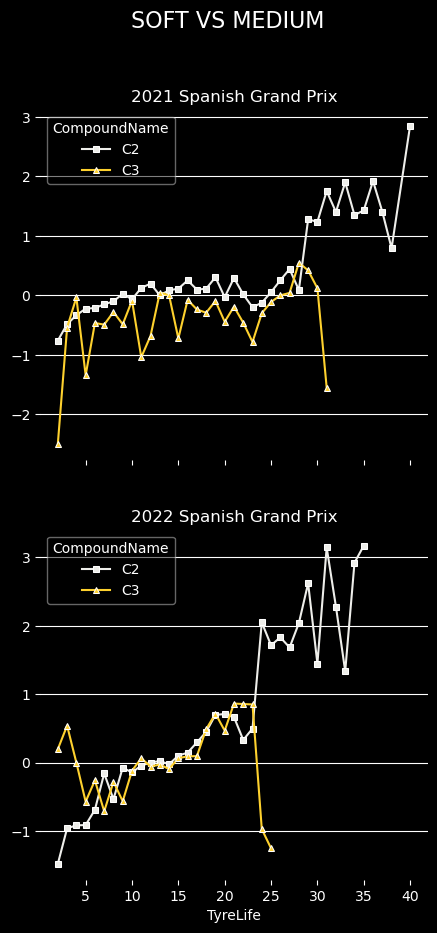

In [48]:
spain_line = plot_compounds_lineplot([2021, 2022], ["Spain", "Spain"], "PctFromLapRep", ["MEDIUM", "SOFT"])

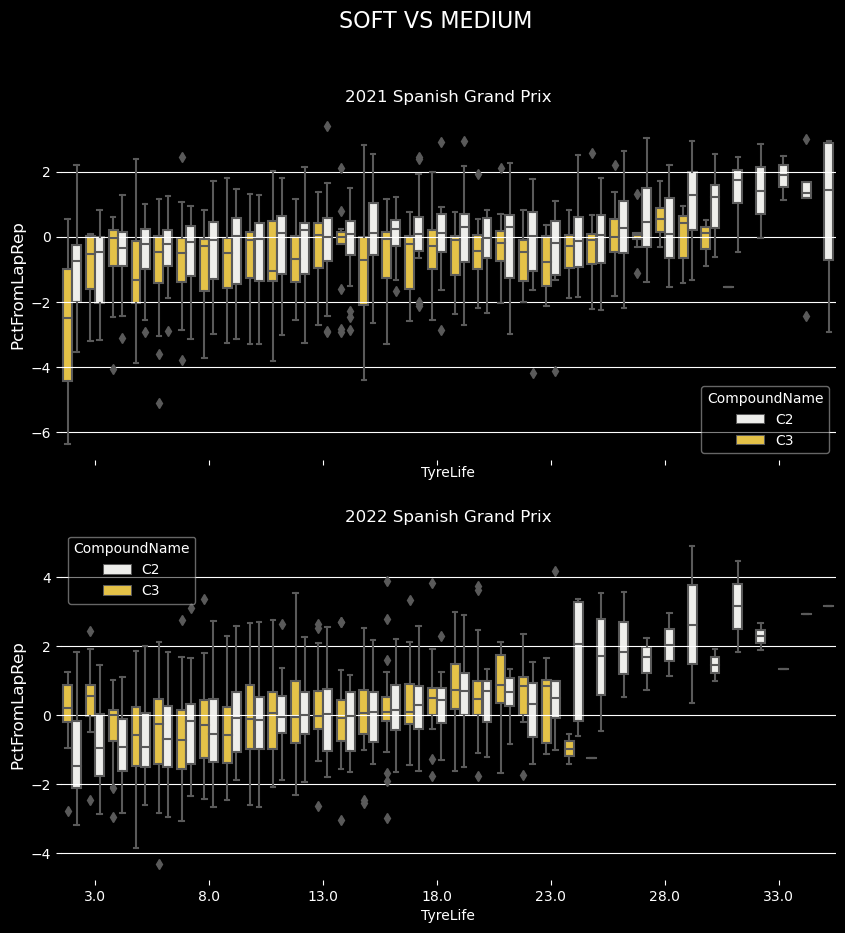

In [49]:
spain_box = plot_compounds_boxplot([2021, 2022], ["Spain", "Spain"], "PctFromLapRep", ["MEDIUM", "SOFT"])

**Spain Analysis**

Soft (C3) and medium (C2) compounds dominate both race. Soft is more prevalent in the 2022 race.

Average stint length on medium is significantly longer in 2021, perhaps suggesting better durability. 

No significant crossover trend in 2021, medium about 1% slower than soft. 

No significant crossover trend in 2022, medium on pace with soft.

Medium compound pace drops significantly after 25~30 laps, this can explain the avergae stint length we see.

### Azerbaijan

In [50]:
print(df_lap_count_2021.loc["Azerbaijan Grand Prix"])
print(df_lap_count_2022.loc["Azerbaijan Grand Prix"])

          LapNumber
Compound           
HARD            671
MEDIUM           23
SOFT            247
UNKNOWN           2
          LapNumber
Compound           
HARD            616
MEDIUM          261
SOFT             12


In [51]:
print(avg_stint_length(2021, "Azerbaijan"))
print(avg_stint_length(2022, "Azerbaijan"))

        Avg Stint Length
HARD                23.1
MEDIUM               7.7
SOFT                 5.5
        Avg Stint Length
HARD                24.6
MEDIUM              12.4
SOFT                12.0


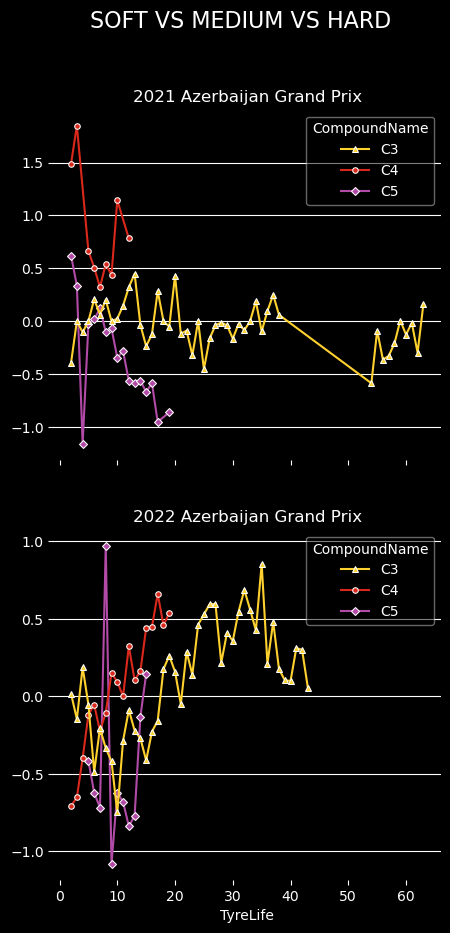

In [52]:
azerbaijan_line = plot_compounds_lineplot([2021, 2022], ["Azerbaijan", "Azerbaijan"], "PctFromLapRep")

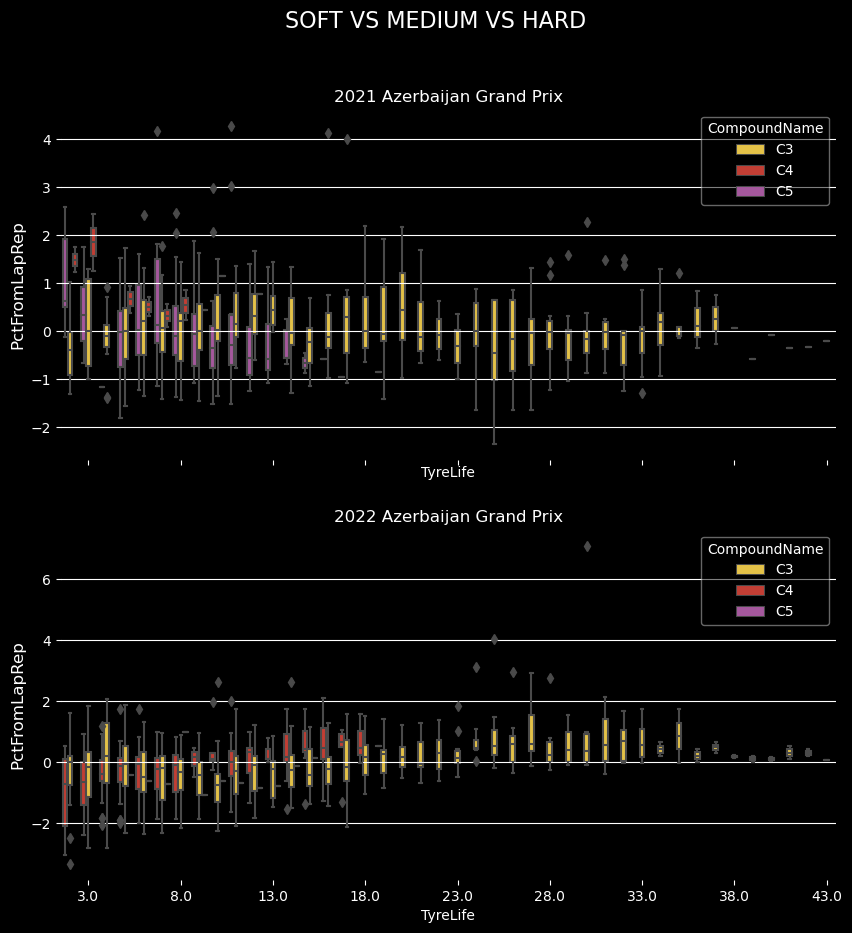

In [53]:
azerbaijan_box = plot_compounds_boxplot([2021, 2022], ["Azerbaijan", "Azerbaijan"], "PctFromLapRep")

**Azerbaijan Analysis**

Hard and soft dominant in 2021 but hard and medium are more prevalent in 2022. 

Weird average stint lengths in 2021 caused by late red flag.

In 2021, C5 about 1% up on C3. No clear crossover trend.

In 2022, average stint length on C3 is comparable to 2021. Crossover trend between hard and medium occurs around 10 laps.

### Silverstone

In [54]:
print(df_lap_count_2021.loc["British Grand Prix"])
print(df_lap_count_2022.loc["British Grand Prix"])

          LapNumber
Compound           
HARD            514
MEDIUM          447
SOFT              9
          LapNumber
Compound           
HARD            183
MEDIUM          413
SOFT            218


In [55]:
print(avg_stint_length(2021, "Silverstone"))
print(avg_stint_length(2022, "Silverstone"))

        Avg Stint Length
HARD                25.7
MEDIUM              11.5
SOFT                 4.5
        Avg Stint Length
HARD                14.1
MEDIUM              12.5
SOFT                10.4


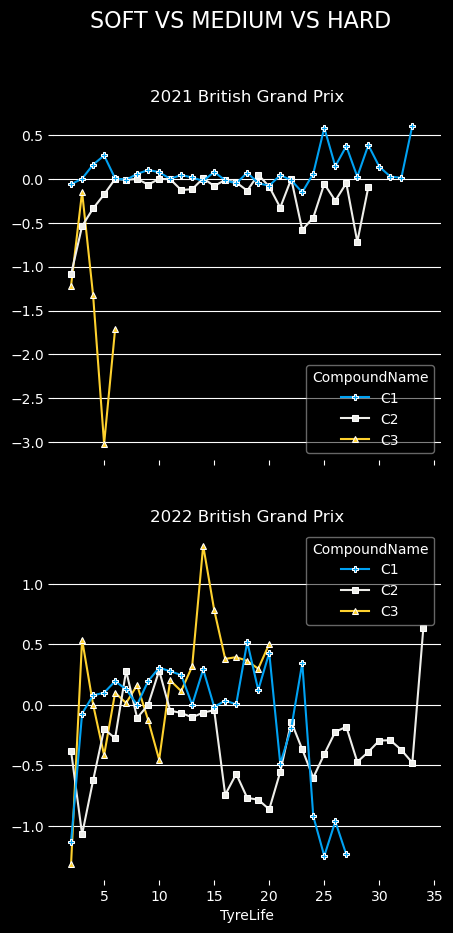

In [56]:
silverstone_line = plot_compounds_lineplot([2021, 2022], ["SilverStone", "Silverstone"], "PctFromLapRep")

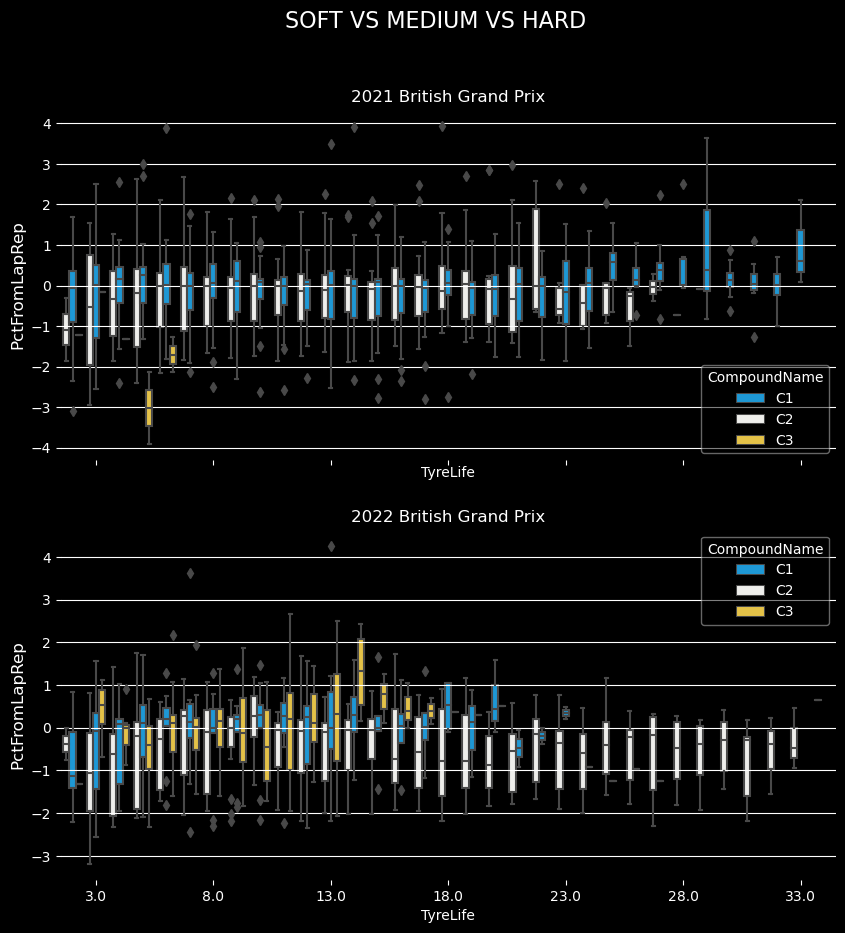

In [57]:
silverstone_box = plot_compounds_boxplot([2021, 2022], ["SilverStone", "Silverstone"], "PctFromLapRep")

**Silverstone Analysis**

C3 is used in 2022 but not in 2021. C3 offers pace advantage over harder compounds in the first 10 or so laps with crossover trend between 12~15 laps. This is reflected in the average stint length of 10.4 laps.

C2 consistently outpaces C1 for at least the first 20 laps. Loss of good sample size after 20 laps in 2022. No clear crossover trend in either event.

C2 advantage on C1 is more significant in 2022. This may explain the lower average stint length and laps raced on C1.

### Austria

In [58]:
print(df_lap_count_2021.loc["Austrian Grand Prix"])
print(df_lap_count_2021.loc["Styrian Grand Prix"])
print(df_lap_count_2022.loc["Austrian Grand Prix"])

          LapNumber
Compound           
HARD            850
MEDIUM          432
SOFT             56
          LapNumber
Compound           
HARD            713
MEDIUM          417
SOFT            166
          LapNumber
Compound           
HARD            887
MEDIUM          424
UNKNOWN          12


In [60]:
print(avg_stint_length(2021, "Austrian Grand Prix"))
print(avg_stint_length(2021, "Styrian Grand Prix"))
print(avg_stint_length(2022, "Austria"))

        Avg Stint Length
HARD                31.5
MEDIUM              27.0
SOFT                14.0
        Avg Stint Length
HARD                35.6
MEDIUM              26.1
SOFT                18.4
        Avg Stint Length
HARD                24.6
MEDIUM              16.3


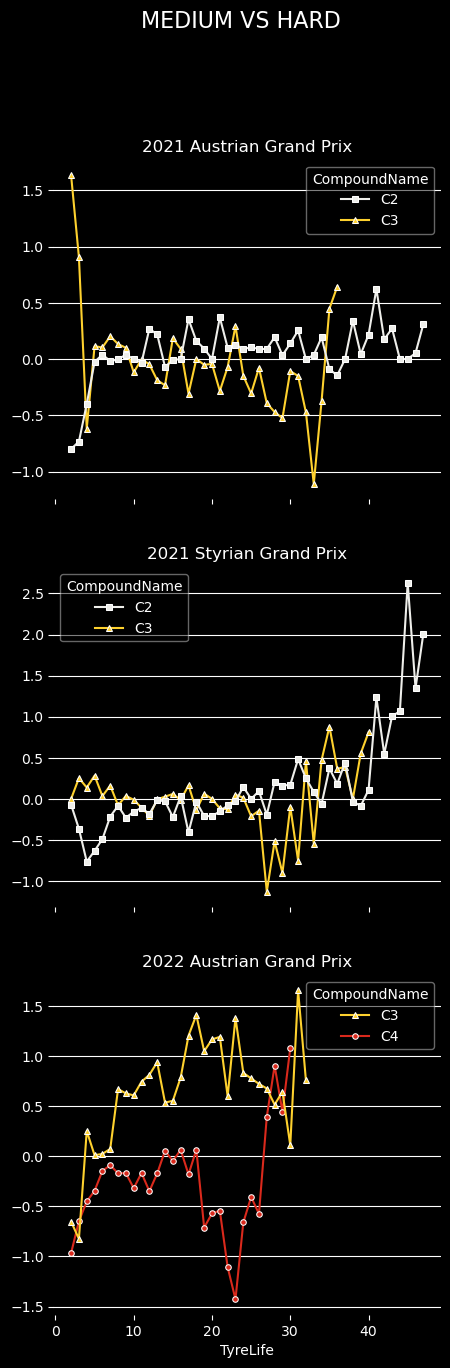

In [79]:
austria_line = plot_compounds_lineplot([2021, 2021, 2022], ["Austrian Grand Prix", "Styrian Grand Prix", "Austria"], "PctFromLapRep", ["MEDIUM", "HARD"], x="TyreLife")

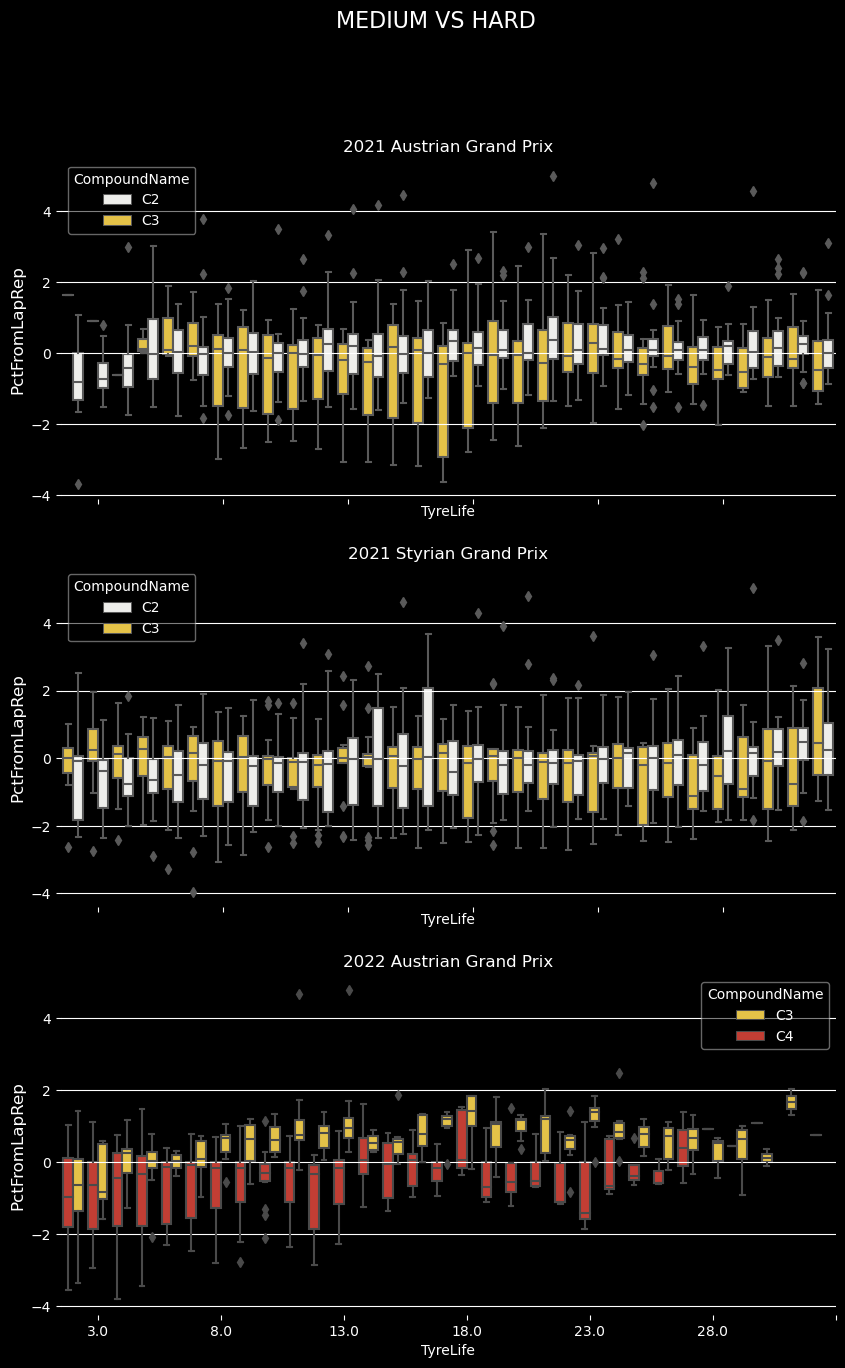

In [73]:
austria_box = plot_compounds_boxplot([2021, 2021, 2022], ["Austrian Grand Prix", "Styrian Grand Prix", "Austria"], "PctFromLapRep", ["MEDIUM", "HARD"])

**Austria Analysis**

The 2022 compound selection is one softer.Medium and hard are the predominant choice in all three races.

Both 2021 races have abover average stint length on C3. No clear crossover trend between C2 and C3. The two compounds are within 0.5% of each other. Significant degradation ramp up for C2 after 35~40 laps.

Fpr the 2022 race,C4 seems to offer 1+% pace advantage at all stages. Further investigation needed.

### France

In [63]:
print(df_lap_count_2021.loc["French Grand Prix"])
print(df_lap_count_2022.loc["French Grand Prix"])

          LapNumber
Compound           
HARD            644
MEDIUM          407
          LapNumber
Compound           
HARD            596
MEDIUM          360


In [64]:
print(avg_stint_length(2021, "French"))
print(avg_stint_length(2022, "French"))

        Avg Stint Length
HARD                32.2
MEDIUM              18.5
        Avg Stint Length
HARD                25.9
MEDIUM              16.4


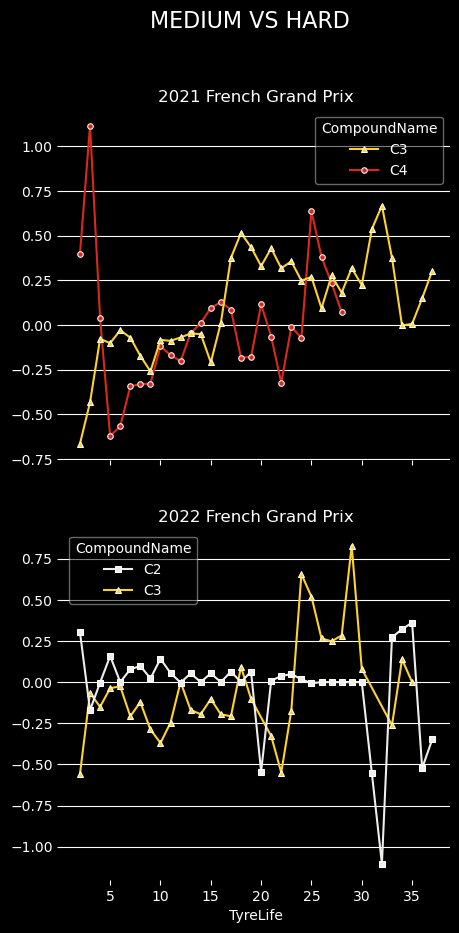

In [67]:
france_line = plot_compounds_lineplot([2021, 2022], ["French", "French"], "PctFromLapRep", ["MEDIUM", "HARD"])

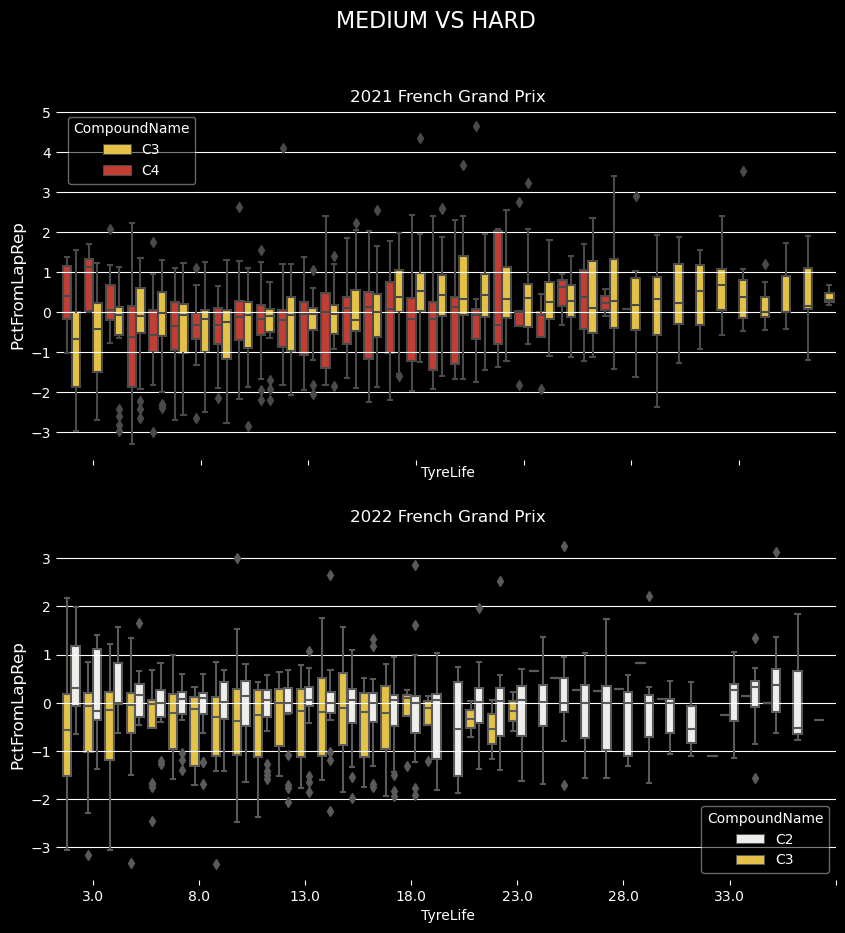

In [68]:
france_box = plot_compounds_boxplot([2021, 2022], ["French", "French"], "PctFromLapRep", ["MEDIUM", "HARD"])

**France Analysis**



### Hungary

In [69]:
print(df_lap_count_2021.loc["Hungarian Grand Prix"])
print(df_lap_count_2022.loc["Hungarian Grand Prix"])

              LapNumber
Compound               
HARD                524
INTERMEDIATE         49
MEDIUM              394
SOFT                 18
          LapNumber
Compound           
HARD            272
MEDIUM          753
SOFT            357


In [70]:
print(avg_stint_length(2021, "Hungarian"))
print(avg_stint_length(2022, "Hungarian"))

              Avg Stint Length
HARD                      37.4
INTERMEDIATE               1.4
MEDIUM                    19.7
SOFT                       9.0
        Avg Stint Length
HARD                30.2
MEDIUM              24.3
SOFT                16.2


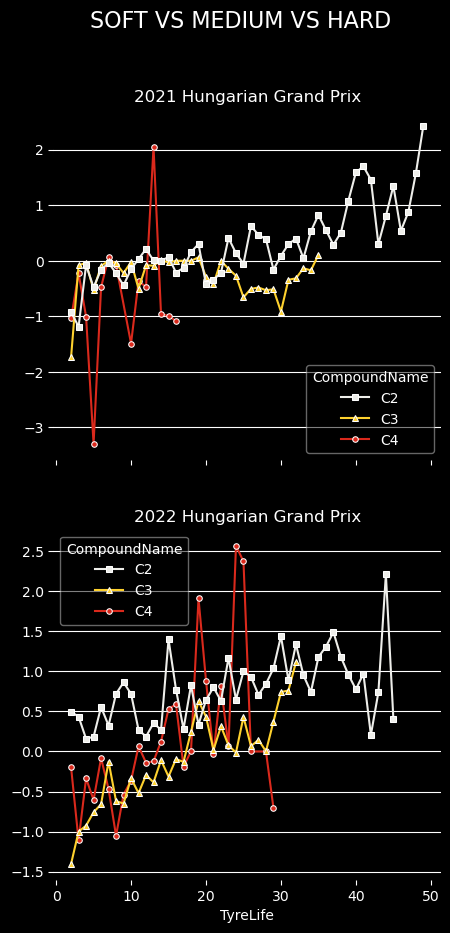

In [83]:
hungary_line = plot_compounds_lineplot([2021, 2022], ["Hungary", "Hungary"], "PctFromLapRep", x="TyreLife")

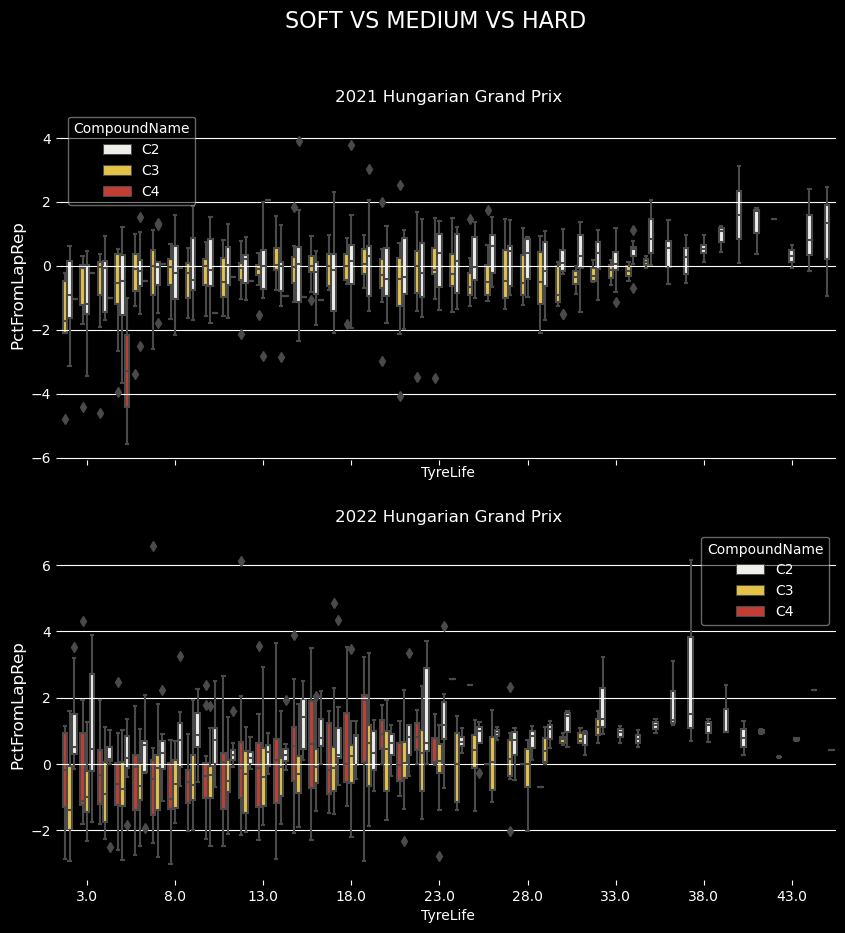

In [72]:
hungary_box = plot_compounds_boxplot([2021, 2022], ["Hungary", "Hungary"], "PctFromLapRep")

**Hungary Analysis**

<AxesSubplot:xlabel='LapNumber', ylabel='sLapTime'>

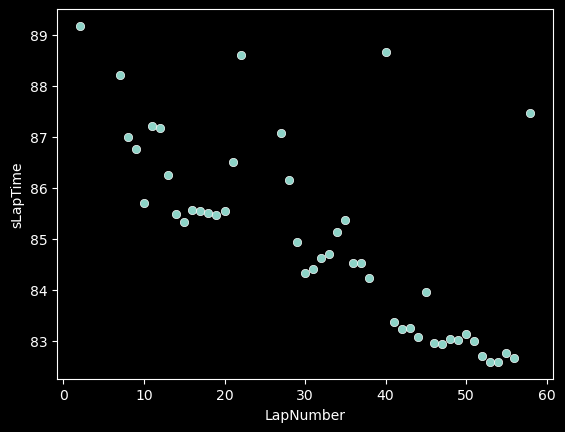

In [90]:
albon_aus_laps = df_laps_2022[(df_laps_2022["EventName"] == "Australian Grand Prix") & (df_laps_2022["Driver"] == "ALB") & (df_laps_2022["sLapTime"] <= 95)][["sLapTime", "LapNumber"]]
sns.scatterplot(data=albon_aus_laps, x="LapNumber", y="sLapTime")